<a href="https://colab.research.google.com/github/Sherry66410/ML-PROJECT/blob/main/Sherry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [92]:
df=pd.read_csv("/content/the_loan.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [94]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [95]:
columns=['Loan_ID']
for col in columns:
  df.drop(col,axis=1,inplace=True)


In [96]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [97]:
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [98]:
columns=['Married','Dependents','Self_Employed']
df=df.dropna(subset=columns)

In [99]:
df.isnull().sum()

,0
Gender,13
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,19
Loan_Amount_Term,12
Credit_History,44


In [100]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

/tmp/ipykernel_168/3565574032.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])


In [101]:
df.loc[:, 'LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [102]:
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

/tmp/ipykernel_168/981078323.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())


In [103]:
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])

/tmp/ipykernel_168/754573792.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])


In [104]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [105]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
columns=['Loan_Status','Married','Education','Self_Employed']
for col in columns:
  df[col]=le.fit_transform(df[col])

/tmp/ipykernel_168/977570921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=le.fit_transform(df[col])
/tmp/ipykernel_168/977570921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=le.fit_transform(df[col])
/tmp/ipykernel_168/977570921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

In [108]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
df_encoded = pd.get_dummies(df[['Dependents', 'Property_Area']], prefix=['Dependents', 'Property_Area'])
df = pd.concat([df, df_encoded], axis=1)
df.drop(['Dependents', 'Property_Area'], axis=1, inplace=True)

display(df.head())

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,Male,0,0,0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,True
1,Male,1,0,0,4583,1508.0,128.0,360.0,1.0,0,False,True,False,False,True,False,False
2,Male,1,0,1,3000,0.0,66.0,360.0,1.0,1,True,False,False,False,False,False,True
3,Male,1,1,0,2583,2358.0,120.0,360.0,1.0,1,True,False,False,False,False,False,True
4,Male,0,0,0,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,True


In [109]:
bool_col=df.select_dtypes(include='bool').columns
df[bool_col]=df[bool_col].astype(int)
df

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,Male,0,0,0,5849,0.0,128.0,360.0,1.0,1,1,0,0,0,0,0,1
1,Male,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,1,0,0,1,0,0
2,Male,1,0,1,3000,0.0,66.0,360.0,1.0,1,1,0,0,0,0,0,1
3,Male,1,1,0,2583,2358.0,120.0,360.0,1.0,1,1,0,0,0,0,0,1
4,Male,0,0,0,6000,0.0,141.0,360.0,1.0,1,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,0,0,0,2900,0.0,71.0,360.0,1.0,1,1,0,0,0,1,0,0
610,Male,1,0,0,4106,0.0,40.0,180.0,1.0,1,0,0,0,1,1,0,0
611,Male,1,0,0,8072,240.0,253.0,360.0,1.0,1,0,1,0,0,0,0,1
612,Male,1,0,0,7583,0.0,187.0,360.0,1.0,1,0,0,1,0,0,0,1


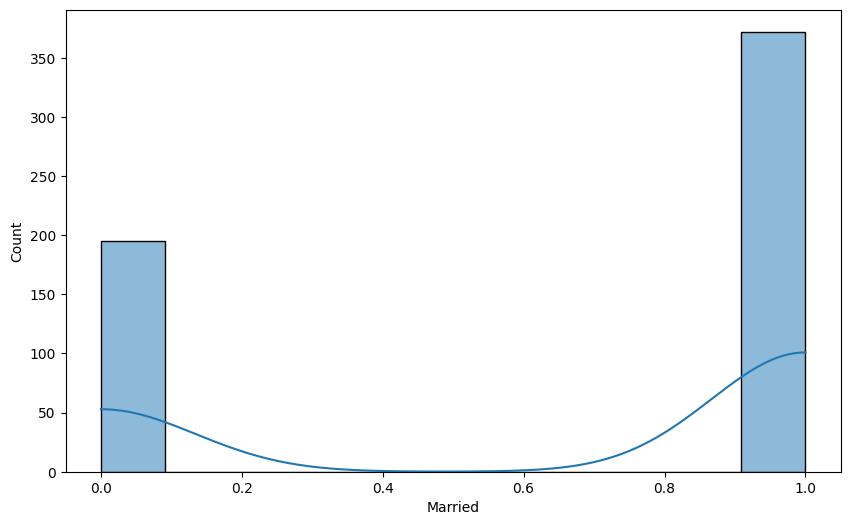

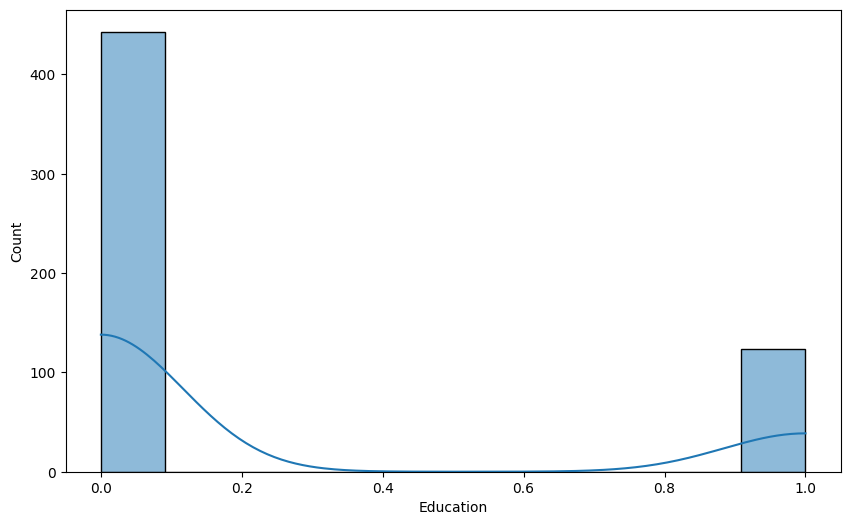

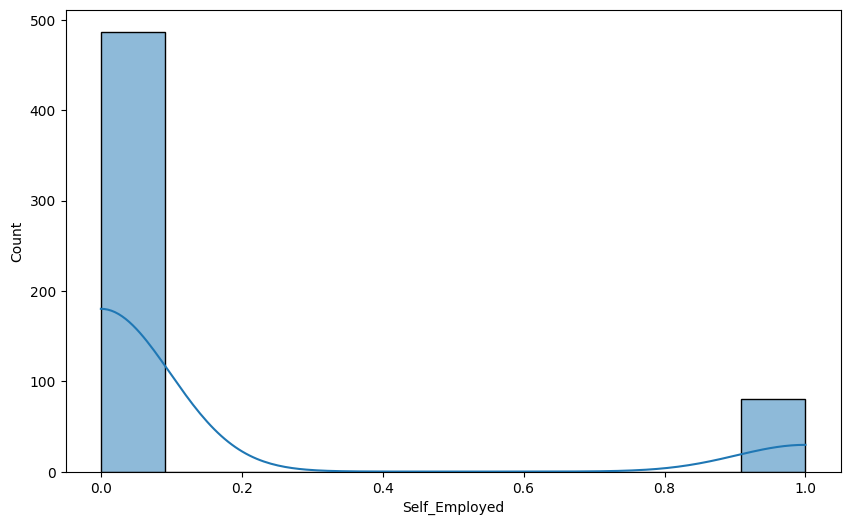

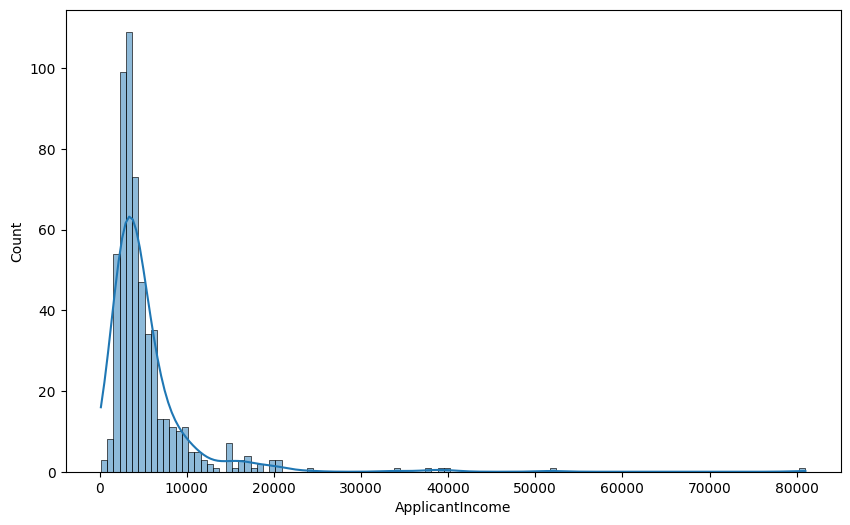

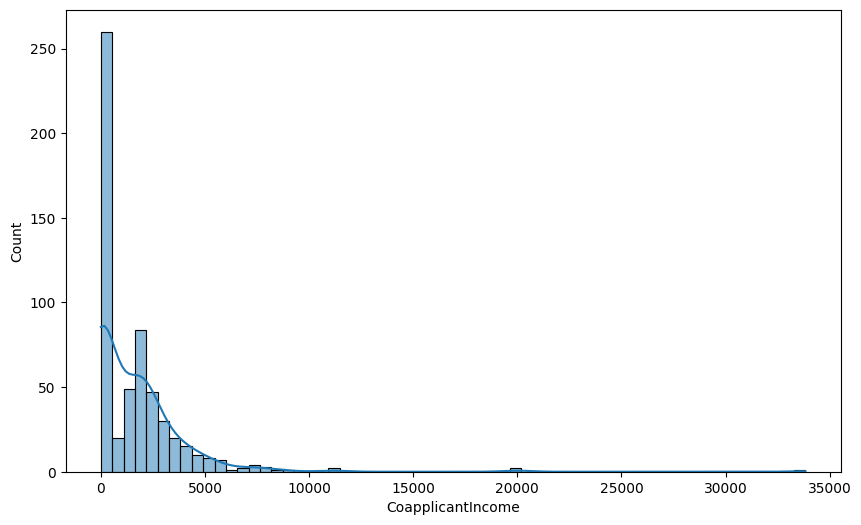

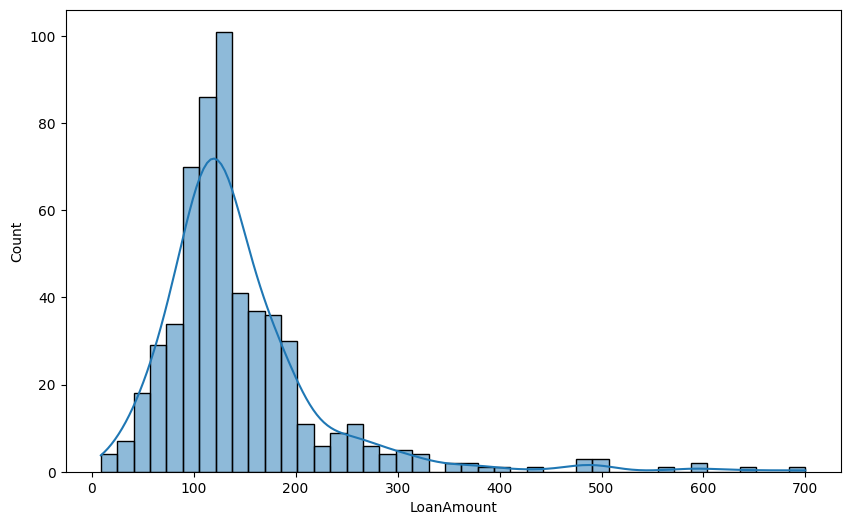

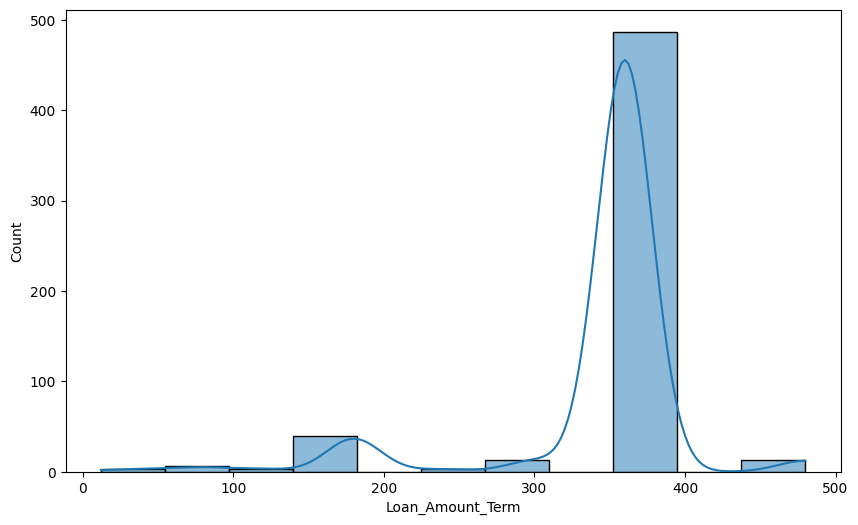

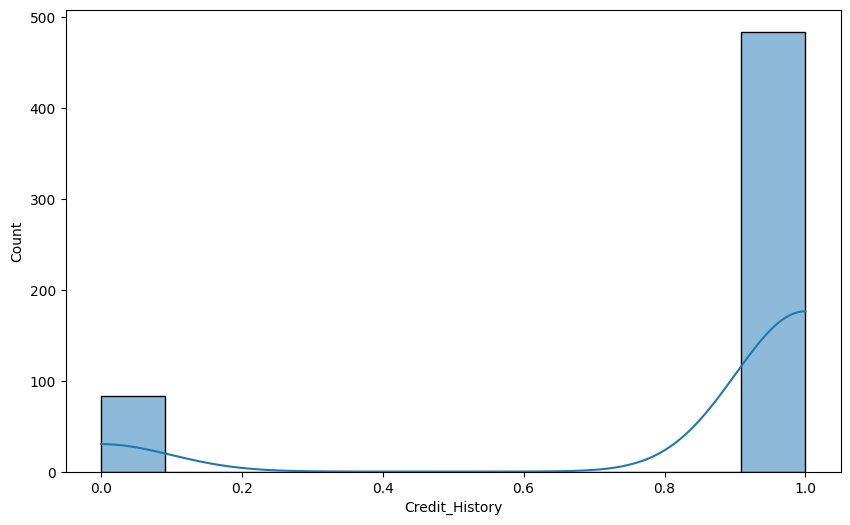

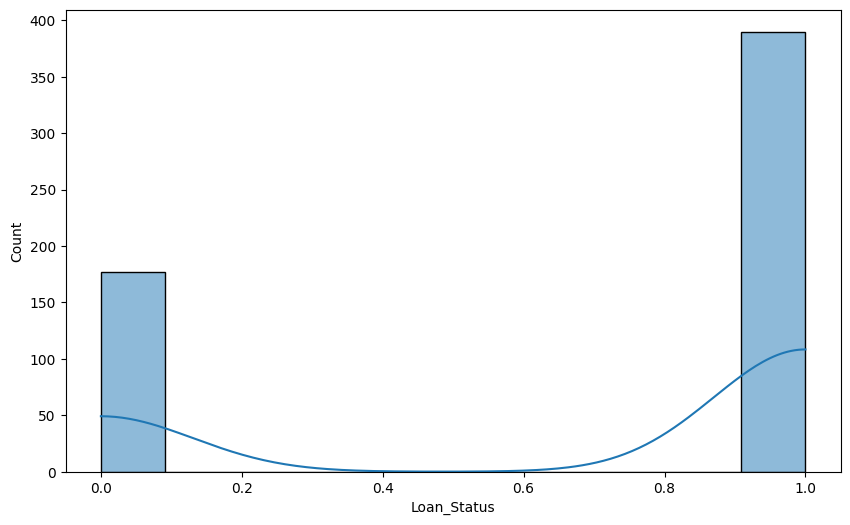

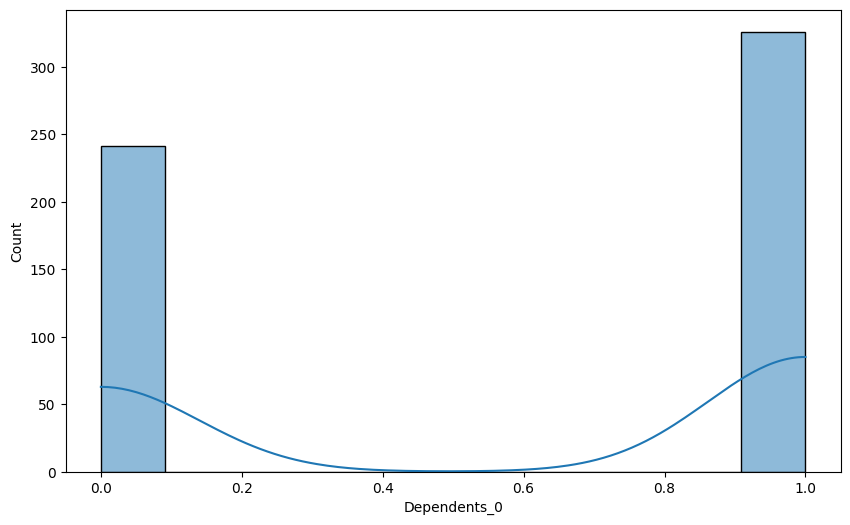

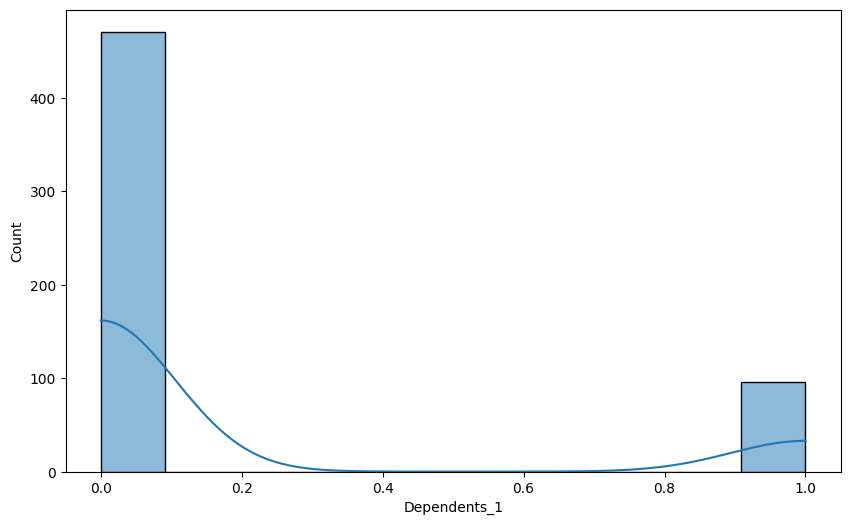

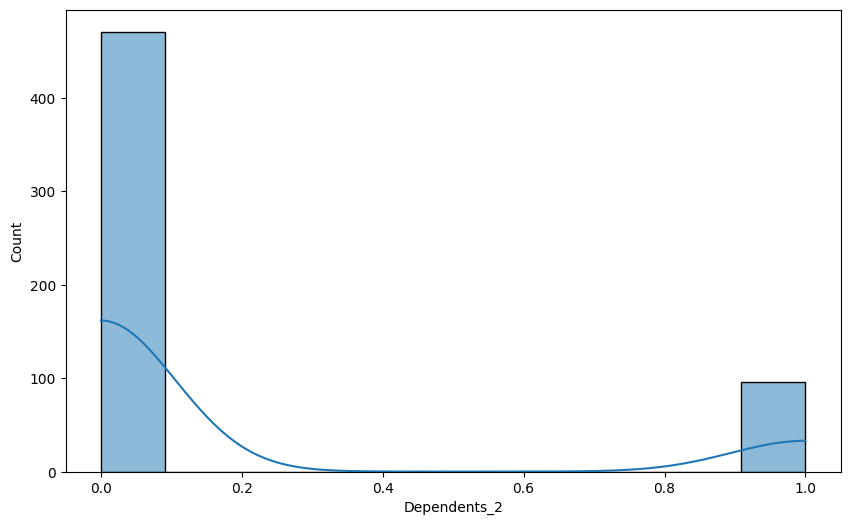

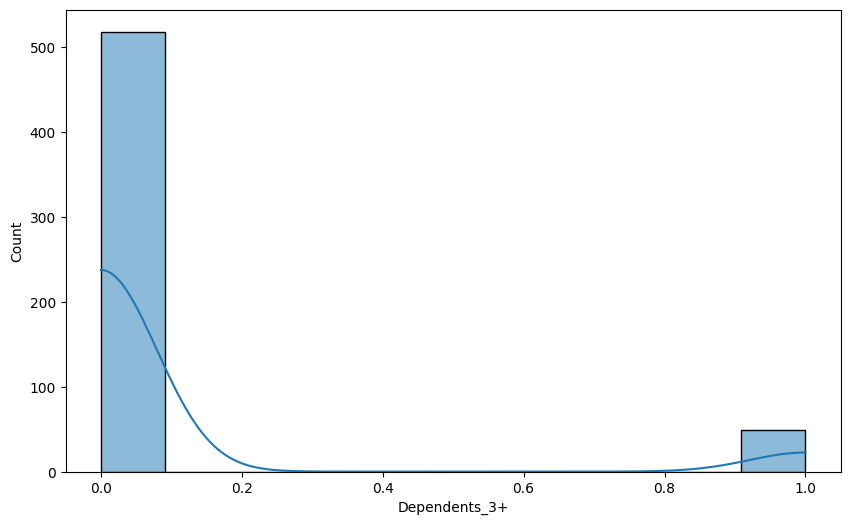

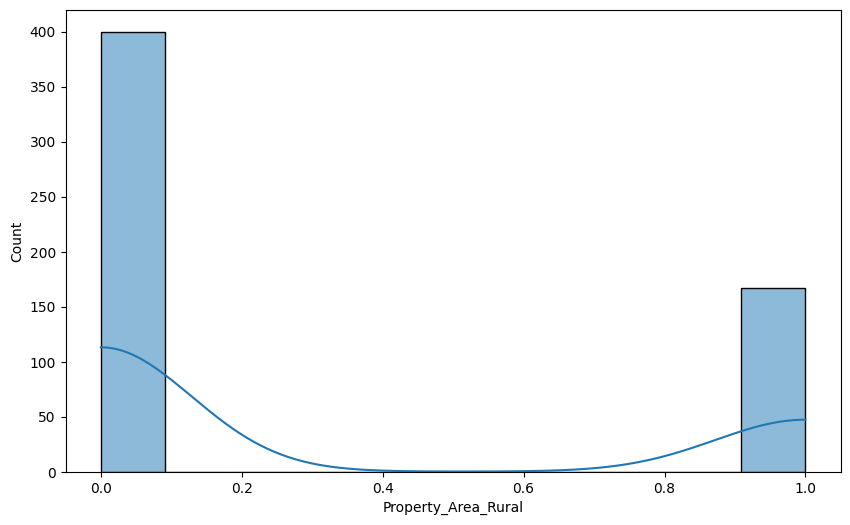

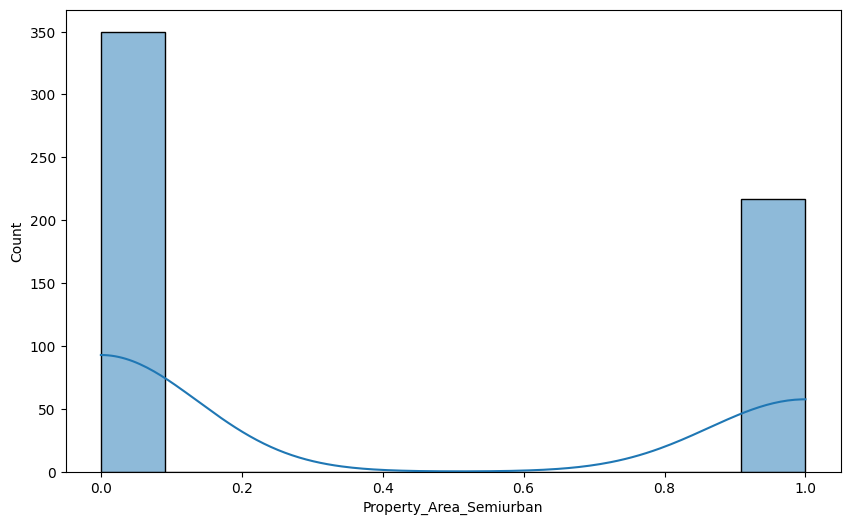

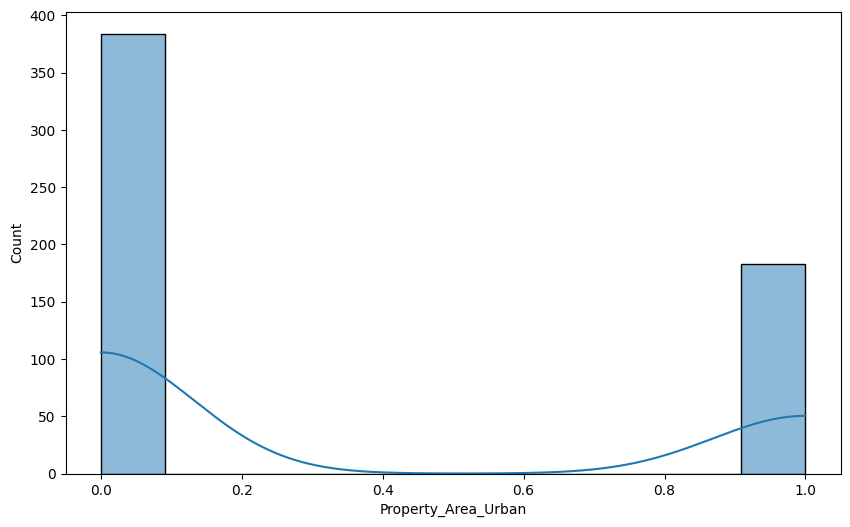

In [115]:
numerical_cols = df.select_dtypes(include=np.number).columns

for column in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], kde=True)
    plt.show()

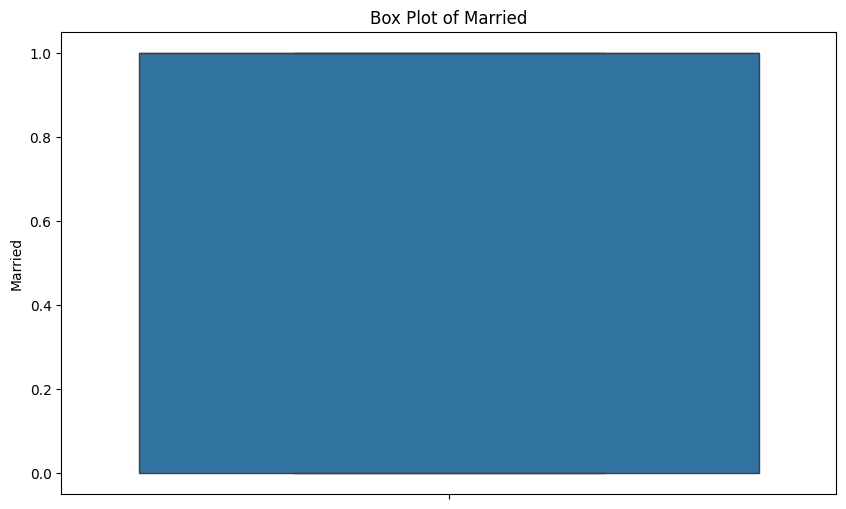

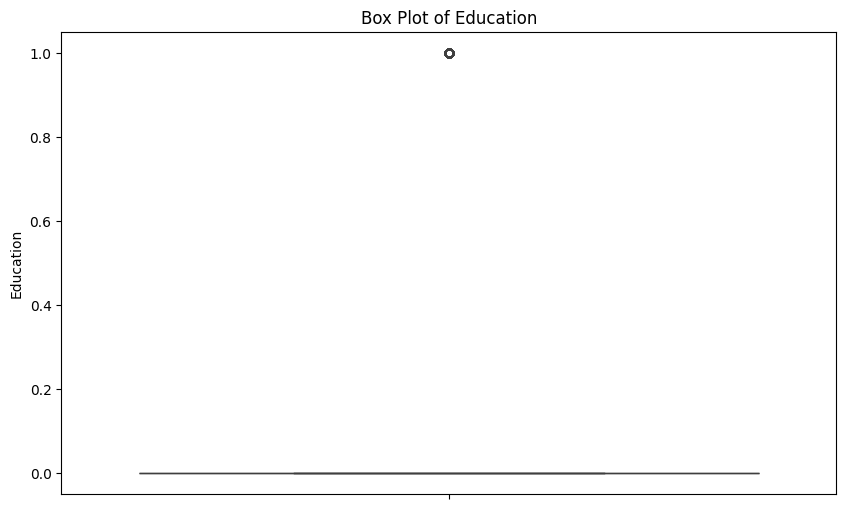

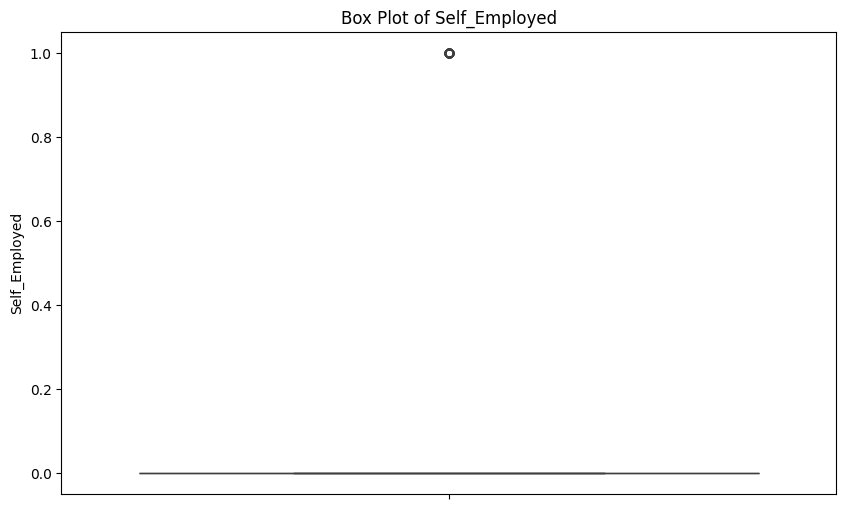

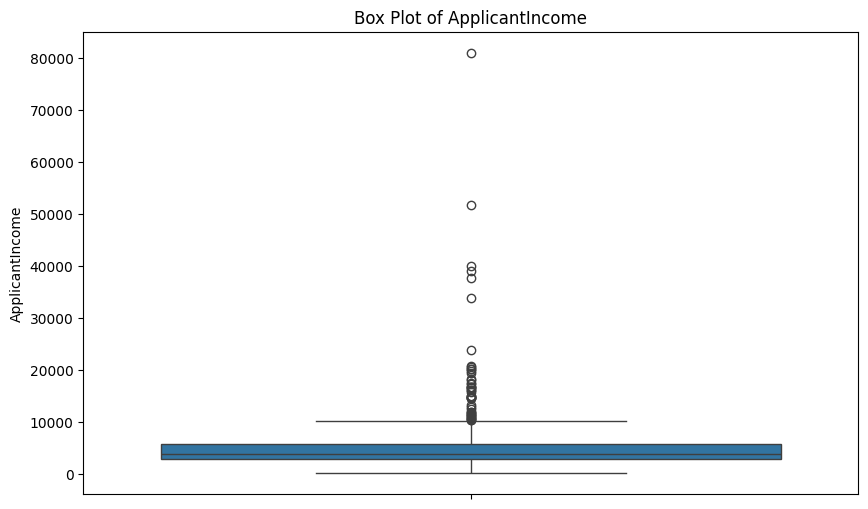

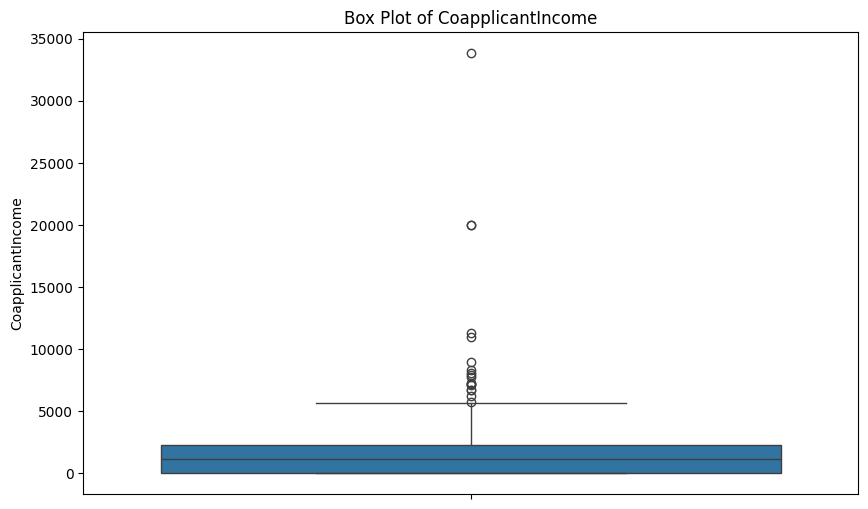

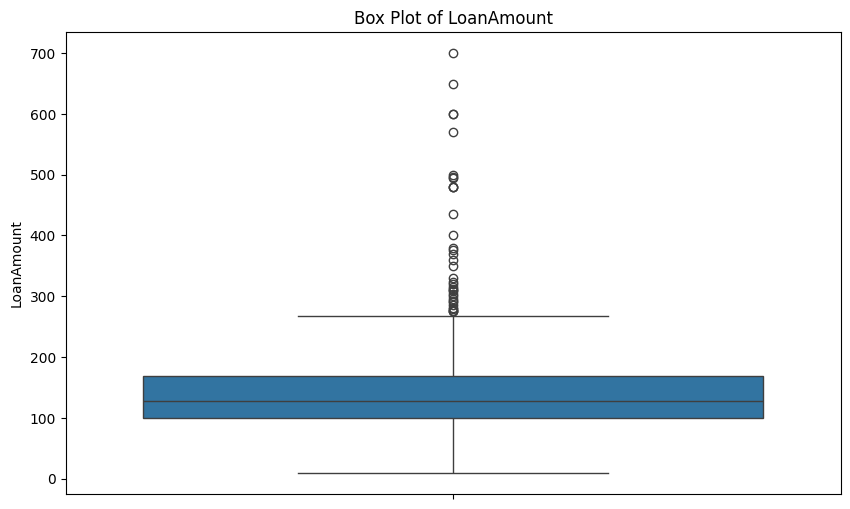

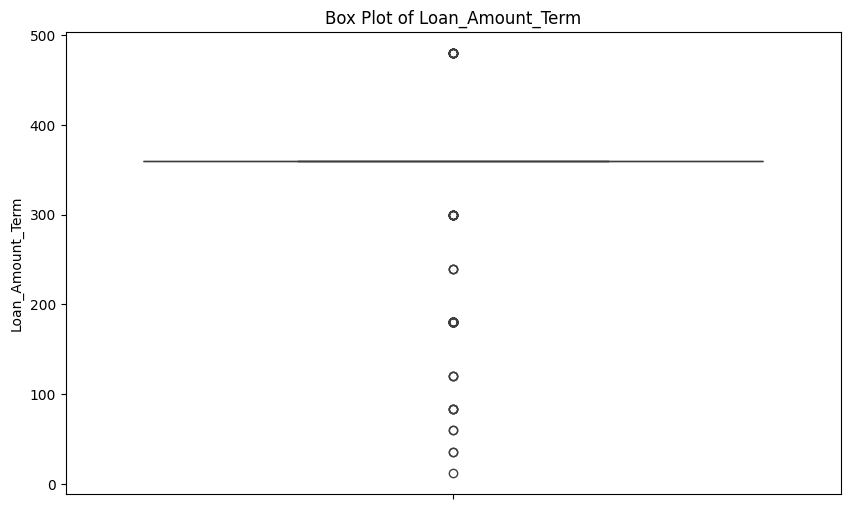

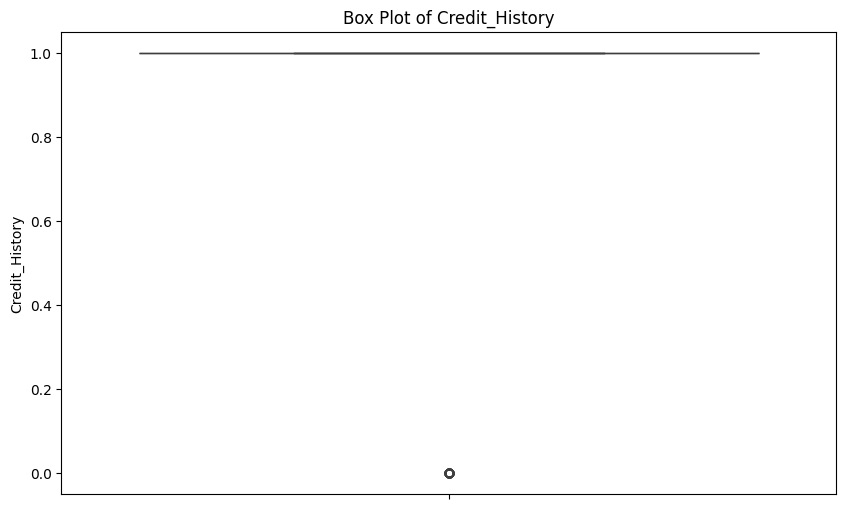

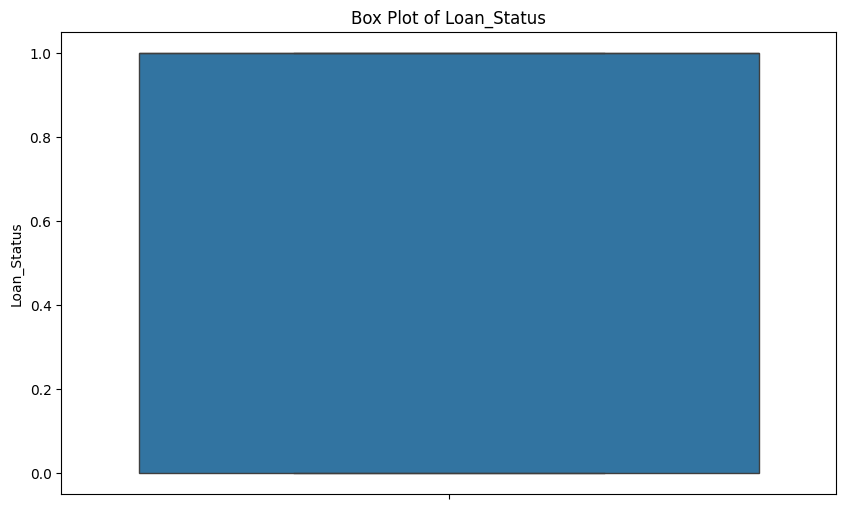

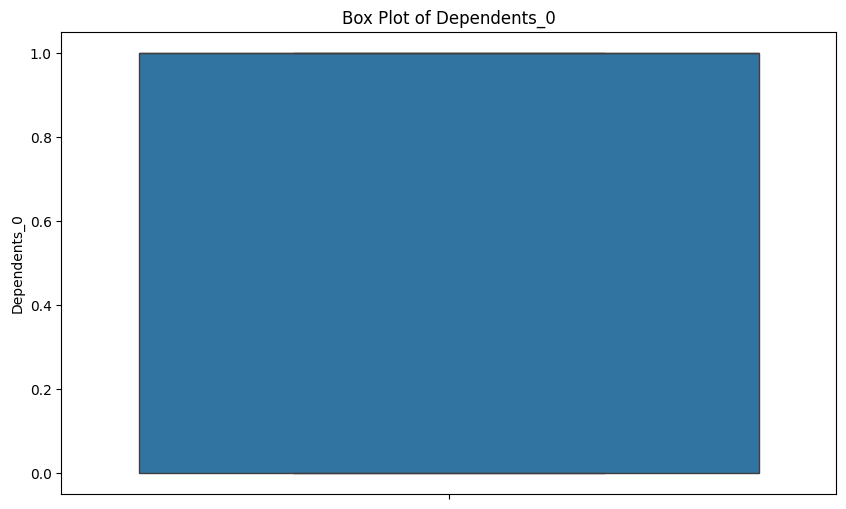

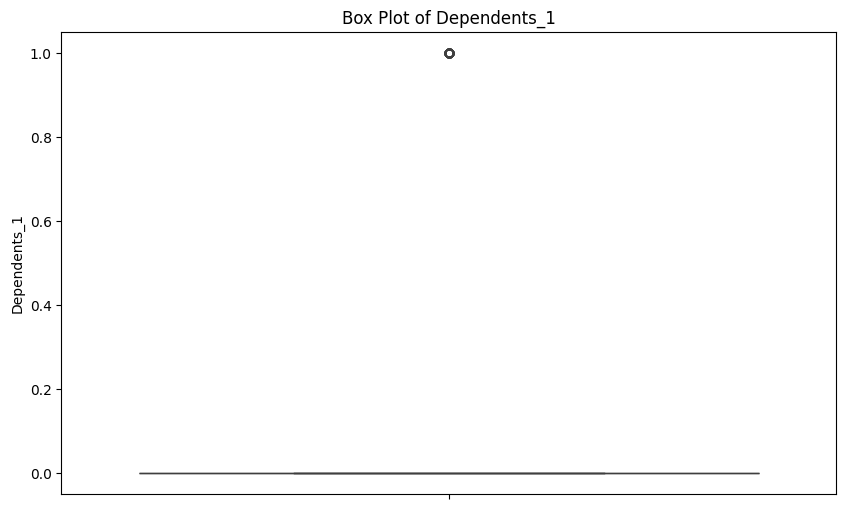

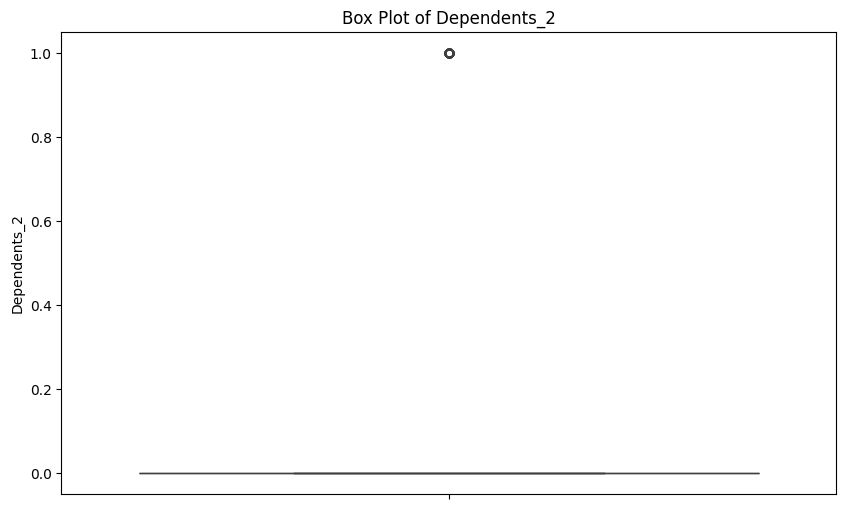

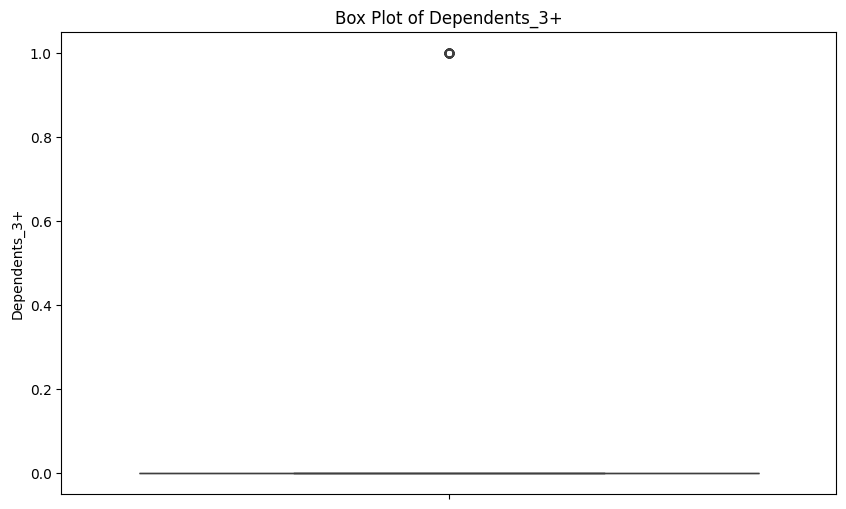

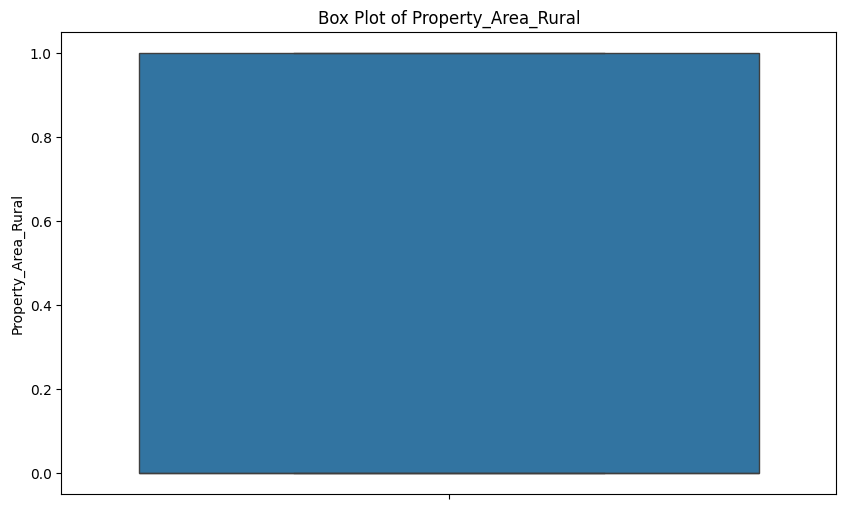

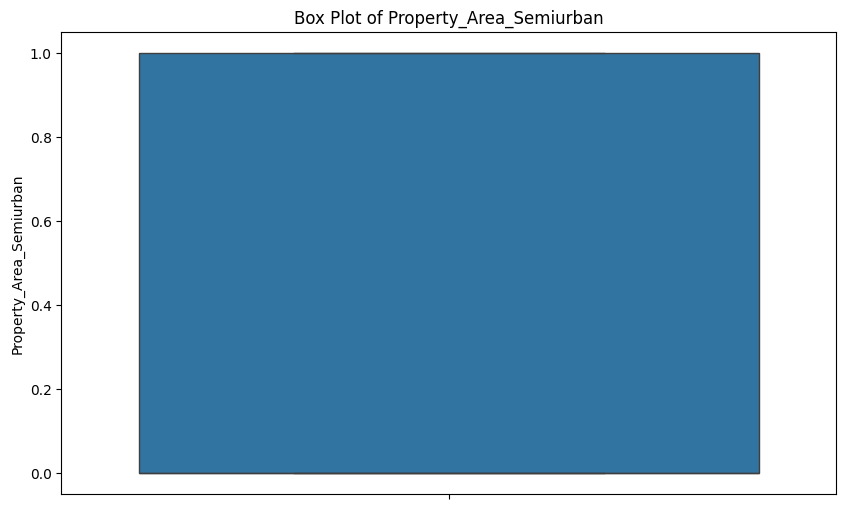

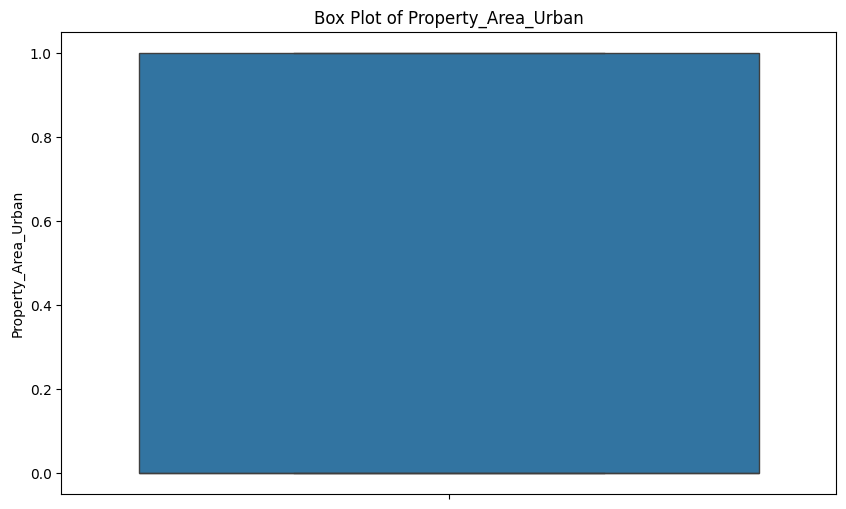

In [111]:
for column in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)
    plt.show()

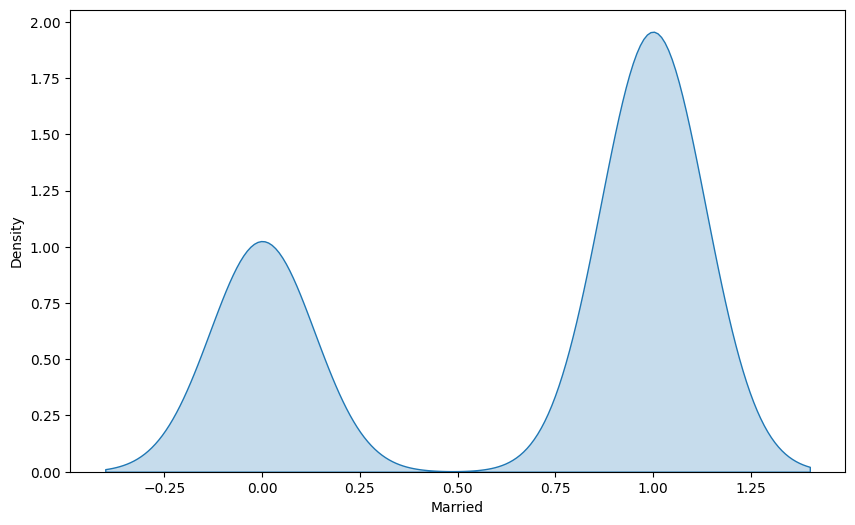

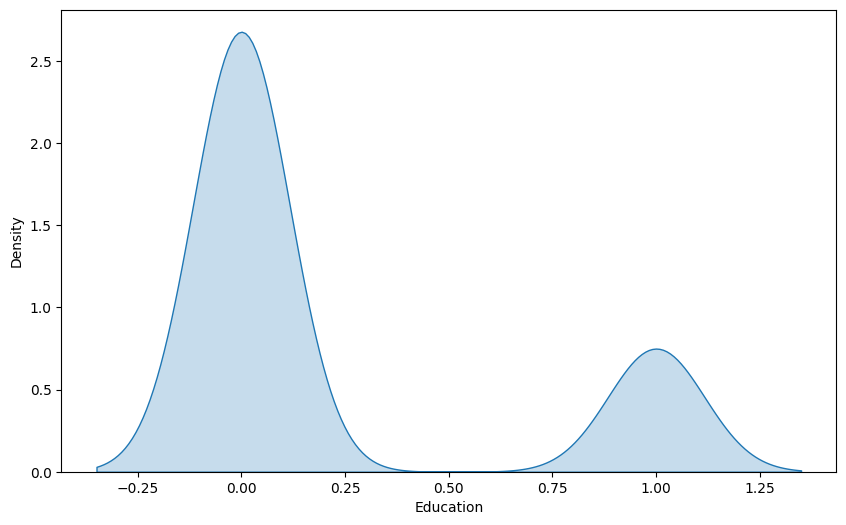

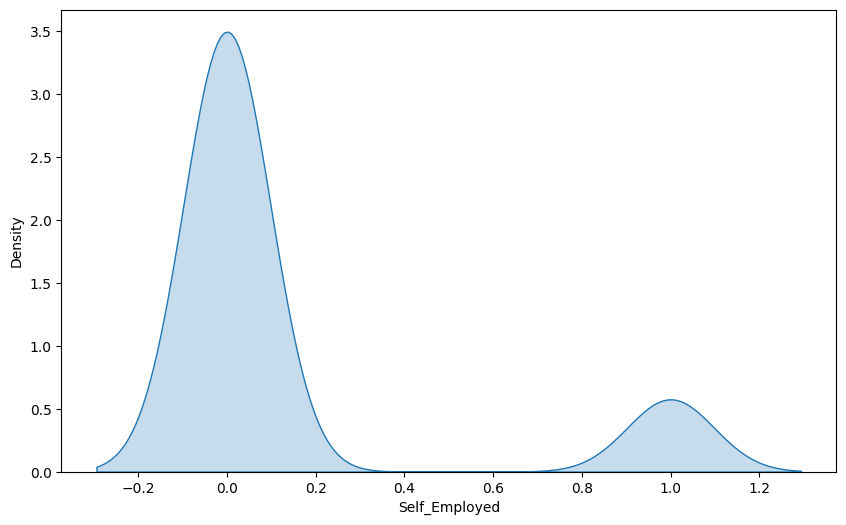

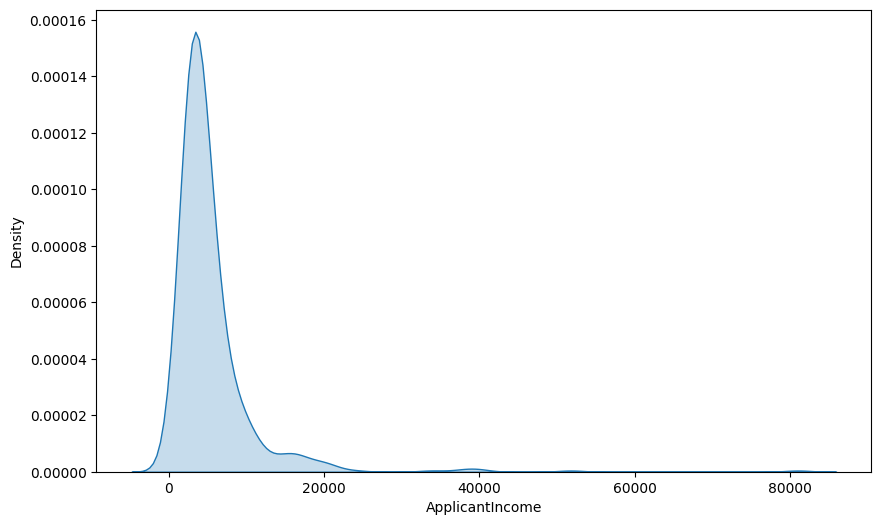

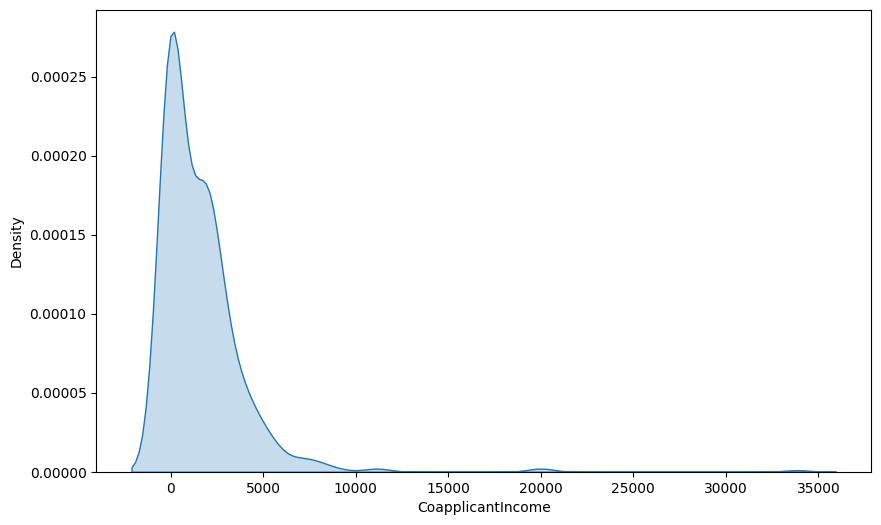

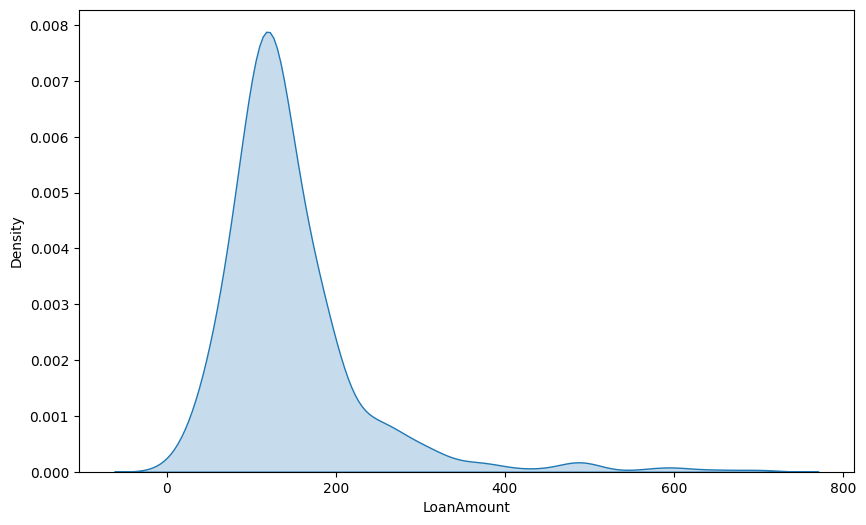

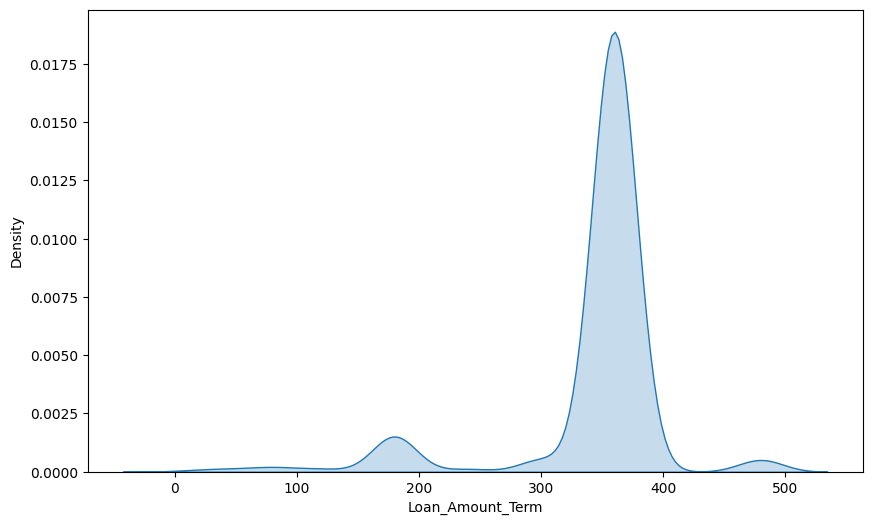

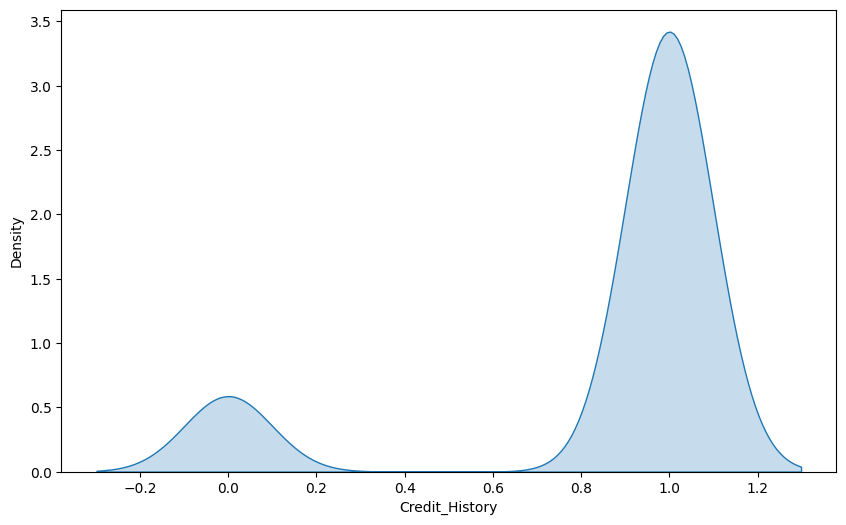

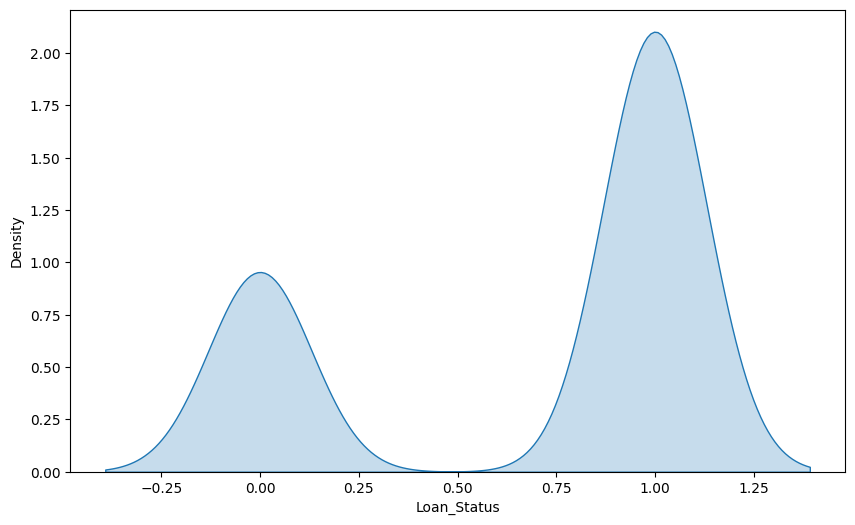

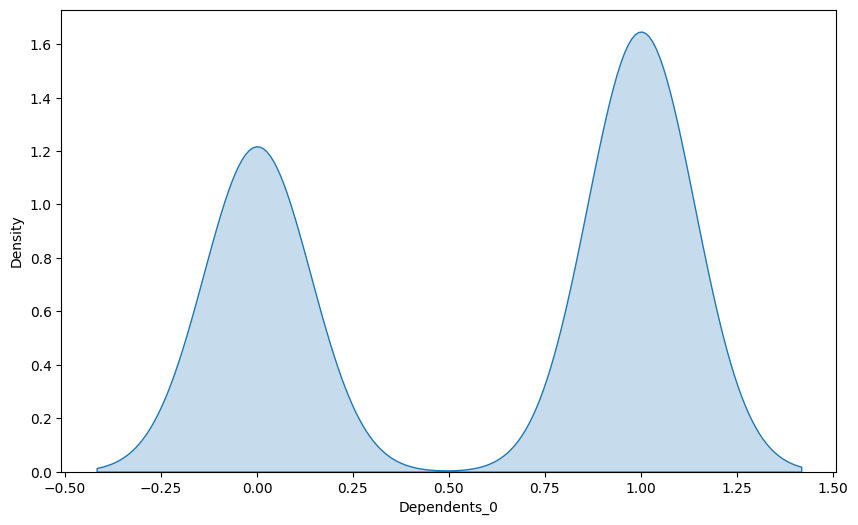

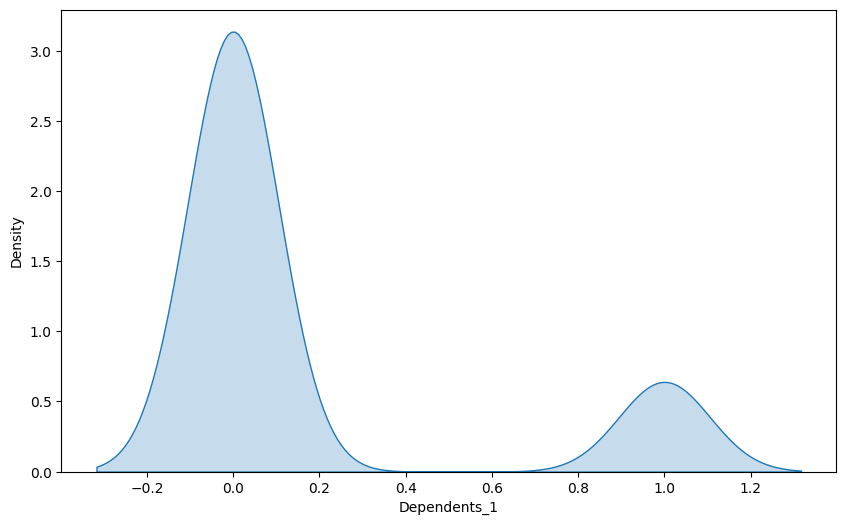

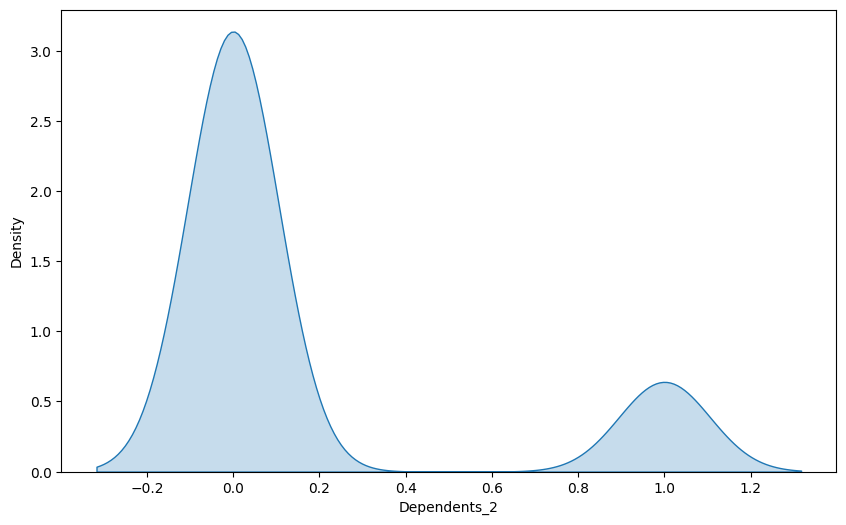

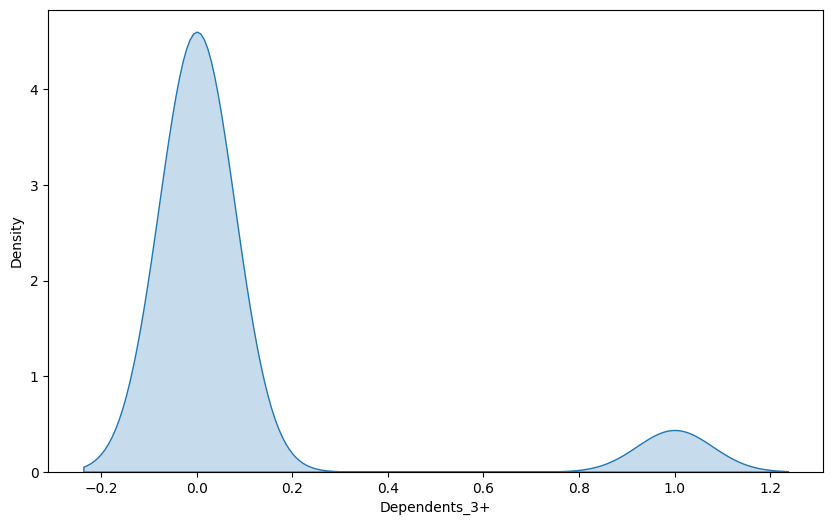

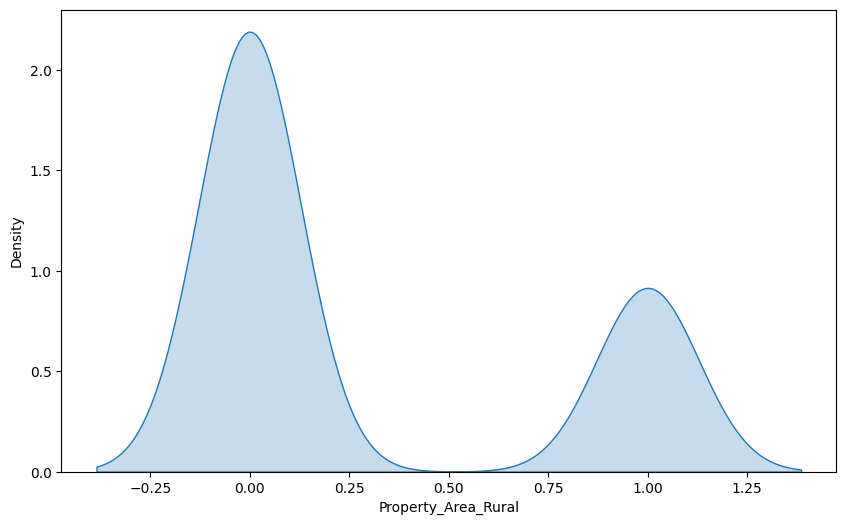

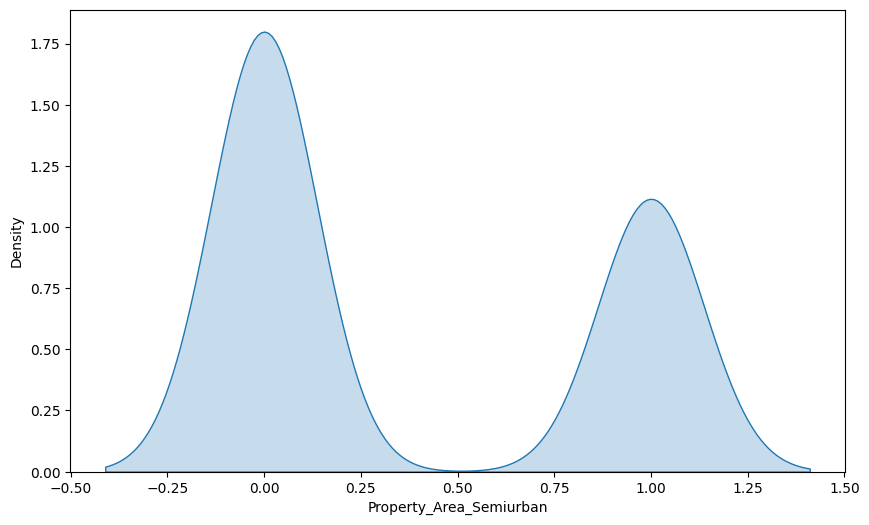

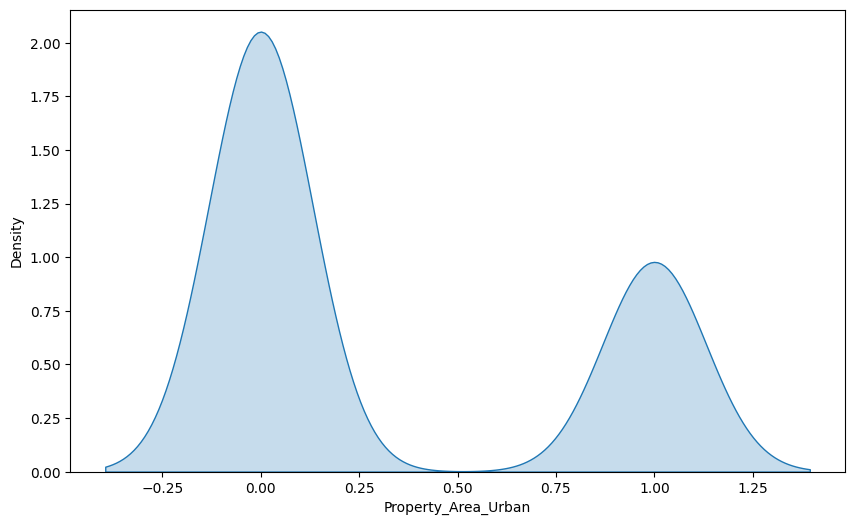

In [116]:
for column in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df[column], fill=True)

    plt.show()

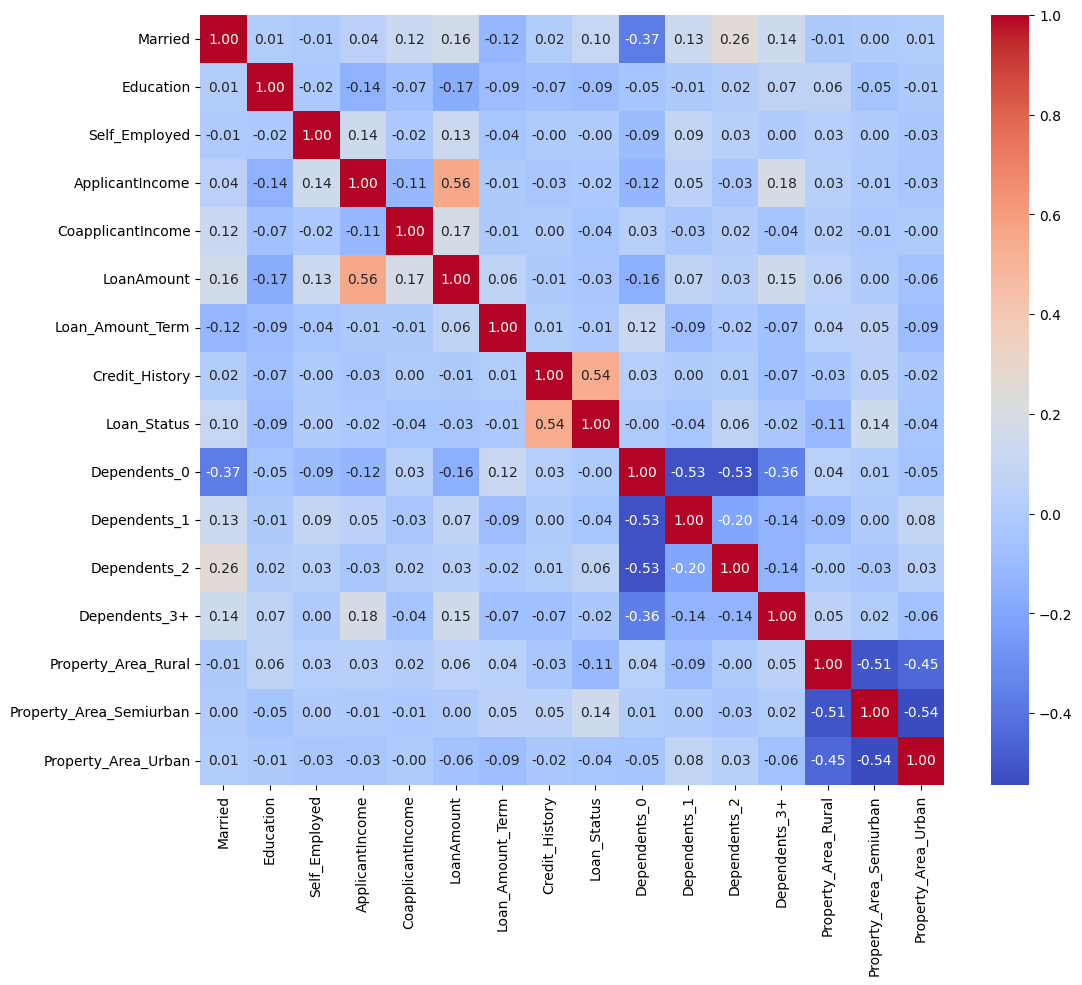

In [114]:
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)

plt.show()

In [120]:

columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

In [121]:
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]



In [122]:
from sklearn.preprocessing import StandardScaler

scaled = df.select_dtypes(include=np.number).columns

scaler = StandardScaler()
df[scaled] = scaler.fit_transform(df[scaled])

df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,Male,-1.307725,-0.575292,-0.360429,1.540385,-0.973741,0.202472,0.0,0.410792,0.637193,0.777914,-0.410792,-0.441461,-0.273336,-0.678924,-0.795731,1.539276
1,Male,0.764687,-0.575292,-0.360429,0.630418,0.173977,0.202472,0.0,0.410792,-1.569383,-1.285489,2.434322,-0.441461,-0.273336,1.472919,-0.795731,-0.649656
2,Male,0.764687,-0.575292,2.774468,-0.507400,-0.973741,-1.626484,0.0,0.410792,0.637193,0.777914,-0.410792,-0.441461,-0.273336,-0.678924,-0.795731,1.539276
3,Male,0.764687,1.738248,-0.360429,-0.807128,0.820901,-0.033522,0.0,0.410792,0.637193,0.777914,-0.410792,-0.441461,-0.273336,-0.678924,-0.795731,1.539276
4,Male,-1.307725,-0.575292,-0.360429,1.648919,-0.973741,0.585963,0.0,0.410792,0.637193,0.777914,-0.410792,-0.441461,-0.273336,-0.678924,-0.795731,1.539276


In [133]:
from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(299, 16)
(75, 16)
(299,)
(75,)


In [136]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)


In [137]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)


In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report

print(accuracy_score(y_test, y_pred_dt))
print(precision_score(y_test, y_pred_dt))
print(recall_score(y_test, y_pred_dt))
print(f1_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

0.7866666666666666
0.8148148148148148
0.88
0.8461538461538461
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        25
           1       0.81      0.88      0.85        50

    accuracy                           0.79        75
   macro avg       0.76      0.74      0.75        75
weighted avg       0.78      0.79      0.78        75



In [139]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


In [145]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report


print(accuracy_score(y_test, y_pred_dt))
print(precision_score(y_test, y_pred_dt))
print(recall_score(y_test, y_pred_dt))
print(f1_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))



0.7866666666666666
0.8148148148148148
0.88
0.8461538461538461
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        25
           1       0.81      0.88      0.85        50

    accuracy                           0.79        75
   macro avg       0.76      0.74      0.75        75
weighted avg       0.78      0.79      0.78        75



In [141]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [147]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report

print(accuracy_score(y_test, y_pred_dt))
print(precision_score(y_test, y_pred_dt))
print(recall_score(y_test, y_pred_dt))
print(f1_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

0.7866666666666666
0.8148148148148148
0.88
0.8461538461538461
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        25
           1       0.81      0.88      0.85        50

    accuracy                           0.79        75
   macro avg       0.76      0.74      0.75        75
weighted avg       0.78      0.79      0.78        75



In [150]:
#Hyperparametric Tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}


In [149]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 100}
Best Score: 0.8327118644067795


In [151]:
tuned_rf_model = RandomForestClassifier(random_state=42, **best_params)
tuned_rf_model.fit(X_train, y_train)
y_pred_tuned_rf = tuned_rf_model.predict(X_test)
print(y_pred_tuned_rf[:5])

[0 0 0 0 1]


In [153]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)

print(accuracy_tuned_rf)
print(precision_tuned_rf)
print(recall_tuned_rf)
print(f1_tuned_rf)
print(classification_report(y_test, y_pred_tuned_rf))

0.8266666666666667
0.8032786885245902
0.98
0.8828828828828829
              precision    recall  f1-score   support

           0       0.93      0.52      0.67        25
           1       0.80      0.98      0.88        50

    accuracy                           0.83        75
   macro avg       0.87      0.75      0.77        75
weighted avg       0.85      0.83      0.81        75

